## Bike Rental Demand Forecasting and Anomaly Detection Across Two Cities

Project Goal

1. Predict hourly bike rental demand.
2. Detect unusual demand spikes and drops.
3. Compare results across 2 independent datasets (Washington DC and Seoul).

Phase 1: Project Setup 

1. Define problem statement in 3-5 lines.
2. Download both datasets from UCI.
3. Create a short data dictionary for each dataset.
4. Confirm target variable:
5. DC dataset: cnt
6. Seoul dataset: Rented Bike Count

Phase 2: Data Cleaning and Standardization 
1. Load both datasets.
2. Parse date and hour fields.
3. Handle missing values (if any).
4. Standardize column names so both datasets share a common schema.
5. Keep core columns:
 datetime
 demand
 temperature
 humidity
 windspeed
 rainfall/snowfall
 holiday
 season

Phase 3: Exploratory Data Analysis

1. Plot demand over time.
2. Compare weekday vs weekend demand.
3. Compare seasonal demand.
4. Analyze weather effect on demand.
5. Write 5-7 key insights.

Phase 4: Feature Engineering

1. Create time features:
 hour
 day_of_week
 month
 is_weekend
2. Create lag features (for time dependency), like previous hour demand.
3. Create rolling mean features (for smoothing), for example 24-hour average.
4. Scale numeric features if model needs it.

 Phase 5: Forecasting Models

1. Build baseline model (Linear Regression or Random Forest Regressor).
2. Train and test on each dataset separately.
3. Evaluate with:
MAE
RMSE
4. Save prediction vs actual values.

Phase 6: Cross-Dataset Generalization 

1. Train on DC, test on Seoul.
2. Train on Seoul, test on DC.
3. Compare error increase/decrease.
4. Explain why transfer works or fails (climate, behavior, holidays, data differences).

Phase 7: Anomaly Detection Using Residuals 

1. Compute residual = actual - predicted.
2. Define anomaly rule:
abs(residual) > 2 or 3 standard deviations
Mark anomalies in timeline plots.
3. Categorize anomalies:
unexpected spike
unexpected drop
4. Discuss possible causes (weather extremes, holidays, events).

Phase 8: Final Report and Presentation 

1. Problem and motivation.
2. Dataset summary (prove 2 independent datasets used).
3. Methods used.
4. Main results and metric tables.
5. Anomaly examples with plots.
6. Limitations and future improvements.

In [2]:
import sys
import subprocess

print("Kernel Python:", sys.executable)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "pip"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib", "pandas", "numpy", "openpyxl"])

Kernel Python: c:\Users\Maxi\Desktop\Data Science\.venv\Scripts\python.exe


0

In [6]:
import sys
print("Using Python:", sys.executable)

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np  


Using Python: c:\Users\Maxi\Desktop\Data Science\.venv\Scripts\python.exe


In [7]:
# Update these paths to where you saved files
dc_path = "data/hour.csv"              # UCI Bike Sharing (DC)
seoul_path = "data/SeoulBikeData.csv"  # UCI Seoul Bike

dc = pd.read_csv(dc_path)
seoul = pd.read_csv(seoul_path, encoding="latin1")

print("DC shape:", dc.shape)
print("Seoul shape:", seoul.shape)

print("\nDC columns:")
print(dc.columns.tolist())

print("\nSeoul columns:")
print(seoul.columns.tolist())

dc.head(), seoul.head()

DC shape: (17379, 17)
Seoul shape: (8760, 14)

DC columns:
['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

Seoul columns:
['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons', 'Holiday', 'Functioning Day']


(   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
 0        1  2011-01-01       1   0     1   0        0        6           0   
 1        2  2011-01-01       1   0     1   1        0        6           0   
 2        3  2011-01-01       1   0     1   2        0        6           0   
 3        4  2011-01-01       1   0     1   3        0        6           0   
 4        5  2011-01-01       1   0     1   4        0        6           0   
 
    weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
 0           1  0.24  0.2879  0.81        0.0       3          13   16  
 1           1  0.22  0.2727  0.80        0.0       8          32   40  
 2           1  0.22  0.2727  0.80        0.0       5          27   32  
 3           1  0.24  0.2879  0.75        0.0       3          10   13  
 4           1  0.24  0.2879  0.75        0.0       0           1    1  ,
          Date  Rented Bike Count  Hour  Temperature(°C)  Humidity(%)  \
 0  01/12/20

In [9]:
seoul

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes


In [10]:
dc

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


In [17]:
# Step 2: Standardize both datasets to same schema

# --- DC dataset ---
dc_std = dc.copy()

# Build datetime from dteday + hr
dc_std["datetime"] = pd.to_datetime(dc_std["dteday"]) + pd.to_timedelta(dc_std["hr"], unit="h")

dc_std = dc_std.rename(columns={
    "cnt": "demand",
    "temp": "temperature",
    "hum": "humidity",
    "holiday": "holiday",
    "season": "season"
})

# Keep a clean comparable subset
dc_std = dc_std[["datetime", "demand", "temperature", "humidity", "windspeed", "holiday", "season"]].copy()
dc_std["rainfall"] = np.nan  # not directly available in DC set
dc_std["city"] = "DC"

# --- Seoul dataset ---
seoul_std = seoul.copy()

# Parse datetime from Date + Hour
seoul_std["datetime"] = pd.to_datetime(seoul_std["Date"], dayfirst=True) + pd.to_timedelta(seoul_std["Hour"], unit="h")

# Handle possible column-name variants in Seoul file
seoul_rename_map = {
    "Rented Bike Count": "demand",
    "Temperature(C)": "temperature",
    "Temperature(°C)": "temperature",
    "Humidity(%)": "humidity",
    "Wind speed (m/s)": "windspeed",
    "Rainfall(mm)": "rainfall",
    "Holiday": "holiday",
    "Seasons": "season",
}
seoul_std = seoul_std.rename(columns=seoul_rename_map)

required_cols = ["datetime", "demand", "temperature", "humidity", "windspeed", "rainfall", "holiday", "season"]
missing_cols = [c for c in required_cols if c not in seoul_std.columns]
if missing_cols:
    print("Seoul columns currently available:")
    print(seoul_std.columns.tolist())
    raise KeyError(f"Missing expected columns after rename: {missing_cols}")

seoul_std = seoul_std[required_cols].copy()
seoul_std["city"] = "Seoul"

# Combine for comparison
combined = pd.concat([dc_std, seoul_std], ignore_index=True)

print("DC standardized:", dc_std.shape)
print("Seoul standardized:", seoul_std.shape)
print("Combined:", combined.shape)
print("\nCombined columns:", combined.columns.tolist())

combined.sample(40)

DC standardized: (17379, 9)
Seoul standardized: (8760, 9)
Combined: (26139, 9)

Combined columns: ['datetime', 'demand', 'temperature', 'humidity', 'windspeed', 'holiday', 'season', 'rainfall', 'city']


,datetime,demand,temperature,humidity,windspeed,holiday,season,rainfall,city
10063,2012-02-29 09:00:00,38,0.30,0.81,0.1642,0,1,NaN,DC
18575,2018-01-19 20:00:00,342,1.20,51.00,0.6000,No Holiday,Winter,0.0,Seoul
3413,2011-05-27 03:00:00,12,0.66,0.65,0.0896,0,2,NaN,DC
586,2011-01-26 17:00:00,26,0.20,0.93,0.3582,0,1,NaN,DC
997,2011-02-14 05:00:00,3,0.32,0.53,0.2836,0,1,NaN,DC
8236,2011-12-14 20:00:00,175,0.34,0.66,0.1045,0,4,NaN,DC
622,2011-01-29 04:00:00,3,0.16,0.69,0.1045,0,1,NaN,DC
10523,2012-03-19 14:00:00,260,0.64,0.57,0.1940,0,1,NaN,DC
1395,2011-03-03 10:00:00,56,0.18,0.29,0.1940,0,1,NaN,DC
11110,2012-04-13 03:00:00,11,0.34,0.61,0.1642,0,2,NaN,DC


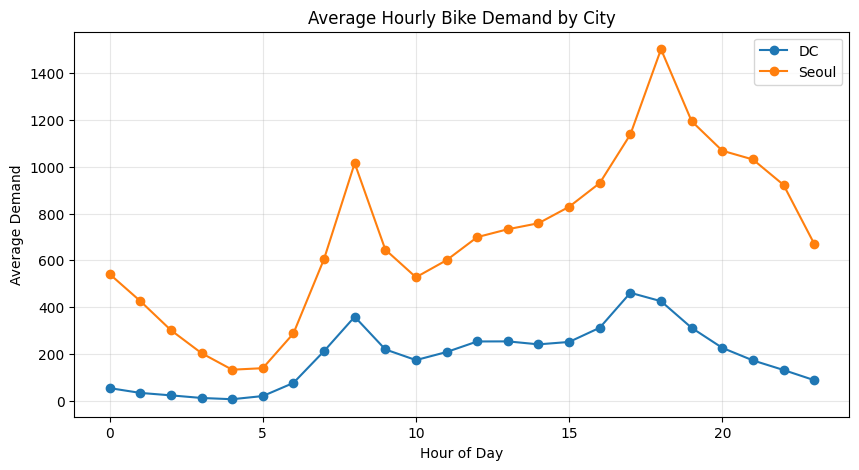

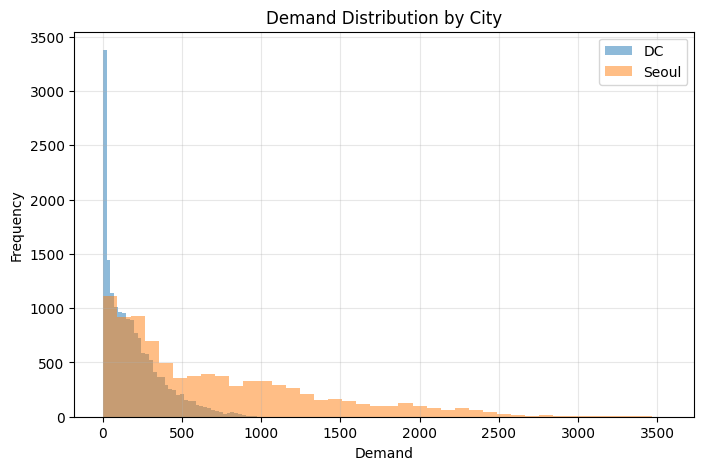

In [18]:
# Step 3: Quick EDA (2 plots)

# 1) Average hourly demand by city
hourly = combined.copy()
hourly["hour"] = hourly["datetime"].dt.hour

avg_hourly = hourly.groupby(["city", "hour"])["demand"].mean().reset_index()

plt.figure(figsize=(10, 5))
for city_name in avg_hourly["city"].unique():
    subset = avg_hourly[avg_hourly["city"] == city_name]
    plt.plot(subset["hour"], subset["demand"], marker="o", label=city_name)

plt.title("Average Hourly Bike Demand by City")
plt.xlabel("Hour of Day")
plt.ylabel("Average Demand")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 2) Demand distribution by city
plt.figure(figsize=(8, 5))
for city_name in combined["city"].unique():
    subset = combined[combined["city"] == city_name]["demand"]
    plt.hist(subset, bins=40, alpha=0.5, label=city_name)

plt.title("Demand Distribution by City")
plt.xlabel("Demand")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Phase 4: Feature Engineering

1. Build model-ready features from time: hour, day_of_week, month, is_weekend
2. Encode city as a numeric column (city_code) for baseline modeling.
3. Fill missing rainfall for DC so the model has no missing values.
4. Create: x = input features, y = target demand

In [25]:
# Step 4.1: Feature engineering from datetime
model_df = combined.copy()

# Time features
model_df["hour"] = model_df["datetime"].dt.hour
model_df["day_of_week"] = model_df["datetime"].dt.dayofweek  # 0=Mon, 6=Sun
model_df["month"] = model_df["datetime"].dt.month
model_df["is_weekend"] = model_df["day_of_week"].isin([5, 6]).astype(int)

# Keep city as numeric for baseline model (DC=0, Seoul=1)
model_df["city_code"] = model_df["city"].map({"DC": 0, "Seoul": 1})

# Replace missing rainfall in DC with 0 for baseline
model_df["rainfall"] = model_df["rainfall"].fillna(0)

# Encode holiday text/number values into binary
holiday_norm = model_df["holiday"].astype(str).str.strip().str.lower()
model_df["holiday_bin"] = holiday_norm.isin(["1", "true", "holiday", "yes"]).astype(int)

# Encode season consistently across both datasets
season_norm = model_df["season"].astype(str).str.strip().str.lower()
season_map = {
    "1": 1, "2": 2, "3": 3, "4": 4,
    "winter": 1, "spring": 2, "summer": 3, "autumn": 4, "fall": 4,
}
model_df["season_code"] = season_norm.map(season_map)
if model_df["season_code"].isna().any():
    print("Unmapped season values:", sorted(model_df.loc[model_df["season_code"].isna(), "season"].astype(str).unique()))
    raise ValueError("Found season values that are not mapped.")
model_df["season_code"] = model_df["season_code"].astype(int)

# Final baseline feature set
feature_cols = [
    "temperature", "humidity", "windspeed", "rainfall",
    "holiday_bin", "season_code", "hour", "day_of_week", "month", "is_weekend", "city_code"
]

X = model_df[feature_cols].copy()
y = model_df["demand"].copy()

print("Model table shape:", model_df.shape)
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nMissing values in features:")
print(X.isna().sum())

model_df.head()

Model table shape: (26139, 16)
Feature matrix shape: (26139, 11)
Target shape: (26139,)

Missing values in features:
temperature    0
humidity       0
windspeed      0
rainfall       0
holiday_bin    0
season_code    0
hour           0
day_of_week    0
month          0
is_weekend     0
city_code      0
dtype: int64


,datetime,demand,temperature,humidity,windspeed,holiday,season,rainfall,city,hour,day_of_week,month,is_weekend,city_code,holiday_bin,season_code
0,2011-01-01 00:00:00,16,0.24,0.81,0.0,0,1,0.0,DC,0,5,1,1,0,0,1
1,2011-01-01 01:00:00,40,0.22,0.80,0.0,0,1,0.0,DC,1,5,1,1,0,0,1
2,2011-01-01 02:00:00,32,0.22,0.80,0.0,0,1,0.0,DC,2,5,1,1,0,0,1
3,2011-01-01 03:00:00,13,0.24,0.75,0.0,0,1,0.0,DC,3,5,1,1,0,0,1
4,2011-01-01 04:00:00,1,0.24,0.75,0.0,0,1,0.0,DC,4,5,1,1,0,0,1


Installs and imports ML tools

It ensures scikit-learn is available, then imports:

train/test split

Linear Regression

MAE and RMSE metrics

Splits data into train and test sets

Uses X and y from your previous feature-engineering cell.

test_size=0.2 means 80 percent training, 20 percent testing.

random_state=42 makes the split reproducible.

Trains the model

Creates LinearRegression().

Fits it on training data with fit(X_train, y_train).

The model learns a linear formula to predict demand from your features.

Makes predictions

Uses predict(X_test) to estimate demand for unseen test rows.

Stores predictions in y_pred.

Evaluates prediction quality

MAE: average absolute error in demand units.

RMSE: penalizes large errors more strongly than MAE.

Your outputs were:

MAE = 191.148

RMSE = 299.787

Meaning: prediction error is still high, but this is normal for a first baseline.

Builds a quick results table

Creates results_df with actual vs predicted values.

results_df.head() lets you inspect how close predictions are row by row.

In [29]:
# Step 5: Baseline forecasting model (Linear Regression)



from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Random split baseline (we will do time-based split later)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("Baseline Linear Regression Results")
print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))

results_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred
})

results_df.head()

Baseline Linear Regression Results
MAE: 191.148
RMSE: 299.787


,actual,predicted
0,13,79.198492
1,209,461.771419
2,343,183.472776
3,234,258.400711
4,59,302.858242


## Sorts by datetime, trains on first 80 percent, tests on last 20 percent, then compares metrics with the random split.

In [30]:
# Step 6: Time-based split evaluation (more realistic for forecasting)

# Sort by time before splitting
time_df = model_df.sort_values("datetime").reset_index(drop=True)
X_time = time_df[feature_cols]
y_time = time_df["demand"]

split_idx = int(len(time_df) * 0.8)
X_train_t, X_test_t = X_time.iloc[:split_idx], X_time.iloc[split_idx:]
y_train_t, y_test_t = y_time.iloc[:split_idx], y_time.iloc[split_idx:]

lr_time = LinearRegression()
lr_time.fit(X_train_t, y_train_t)
y_pred_t = lr_time.predict(X_test_t)

mae_t = mean_absolute_error(y_test_t, y_pred_t)
rmse_t = mean_squared_error(y_test_t, y_pred_t) ** 0.5

print("Time-based Linear Regression Results")
print("MAE:", round(mae_t, 3))
print("RMSE:", round(rmse_t, 3))

comparison_df = pd.DataFrame({
    "split_type": ["random", "time_based"],
    "MAE": [mae, mae_t],
    "RMSE": [rmse, rmse_t],
})

comparison_df

Time-based Linear Regression Results
MAE: 460.759
RMSE: 599.677


,split_type,MAE,RMSE
0,random,191.148384,299.787077
1,time_based,460.759033,599.677437


# intermediate conclusion

The time-based result is much worse, which is common and more realistic for forecasting.
Random split usually looks too optimistic because train and test contain mixed time periods.

# I’ll implement the cross-city generalization step now (train on one city, test on the other) and run it so you get direct comparison metrics.

In [31]:
# Step 7: Cross-city generalization (train one city, test on the other)

# Split model table by city
dc_data = model_df[model_df["city"] == "DC"].copy()
seoul_data = model_df[model_df["city"] == "Seoul"].copy()

X_dc = dc_data[feature_cols]
y_dc = dc_data["demand"]
X_seoul = seoul_data[feature_cols]
y_seoul = seoul_data["demand"]

# A) Train on DC, test on Seoul
model_dc_to_seoul = LinearRegression()
model_dc_to_seoul.fit(X_dc, y_dc)
pred_seoul = model_dc_to_seoul.predict(X_seoul)
mae_dc_to_seoul = mean_absolute_error(y_seoul, pred_seoul)
rmse_dc_to_seoul = mean_squared_error(y_seoul, pred_seoul) ** 0.5

# B) Train on Seoul, test on DC
model_seoul_to_dc = LinearRegression()
model_seoul_to_dc.fit(X_seoul, y_seoul)
pred_dc = model_seoul_to_dc.predict(X_dc)
mae_seoul_to_dc = mean_absolute_error(y_dc, pred_dc)
rmse_seoul_to_dc = mean_squared_error(y_dc, pred_dc) ** 0.5

cross_city_df = pd.DataFrame({
    "experiment": ["Train DC -> Test Seoul", "Train Seoul -> Test DC"],
    "MAE": [mae_dc_to_seoul, mae_seoul_to_dc],
    "RMSE": [rmse_dc_to_seoul, rmse_seoul_to_dc],
})

print("Cross-city generalization results")
cross_city_df

Cross-city generalization results


,experiment,MAE,RMSE
0,Train DC -> Test Seoul,9819.417430,10952.633476
1,Train Seoul -> Test DC,584.886657,622.179344


# what we see

Transfer between cities is weak, especially DC -> Seoul.
One city’s learned pattern does not generalize well to the other.
This is a strong finding for your report (different demand scale/behavior/context).

_________________________________________________________________________

# Residual-based anomaly detection on the time-based model:

Residual std: 592.855
Anomaly threshold (2*std): 1185.71
Total test rows: 5228
Anomalies found: 307
Anomaly rate (%): 5.87

By type:
anomaly_type
normal              4921
unexpected_spike     304
unexpected_drop        3
Name: count, dtype: int64


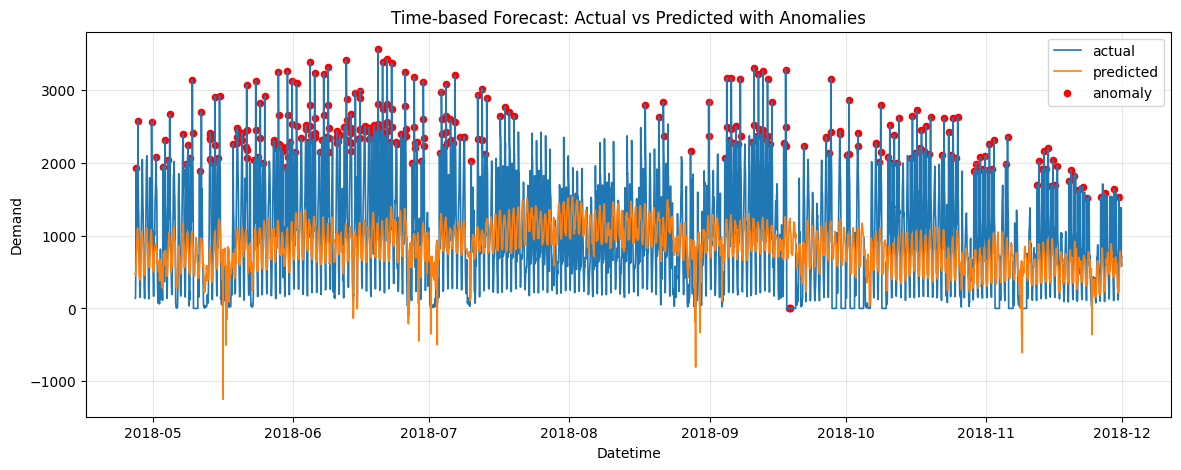

,datetime,city,demand,predicted_demand,residual,anomaly_type
22197,2018-06-19 18:00:00,Seoul,3556,1062.432467,2493.567533,unexpected_spike
22029,2018-06-12 18:00:00,Seoul,3404,1107.814627,2296.185373,unexpected_spike
21837,2018-06-04 18:00:00,Seoul,3380,1103.134099,2276.865901,unexpected_spike
22221,2018-06-20 18:00:00,Seoul,3384,1152.410318,2231.589682,unexpected_spike
22245,2018-06-21 18:00:00,Seoul,3418,1230.235337,2187.764663,unexpected_spike
21933,2018-06-08 18:00:00,Seoul,3309,1131.593306,2177.406694,unexpected_spike
21717,2018-05-30 18:00:00,Seoul,3251,1084.138224,2166.861776,unexpected_spike
24357,2018-09-17 18:00:00,Seoul,3277,1126.195080,2150.804920,unexpected_spike
22389,2018-06-27 18:00:00,Seoul,3172,1021.536230,2150.463770,unexpected_spike
21213,2018-05-09 18:00:00,Seoul,3130,1009.922835,2120.077165,unexpected_spike


In [32]:
# Step 8: Residual-based anomaly detection (using time-based model)

# Build evaluation frame for the test period (last 20% in time order)
eval_df = time_df.iloc[split_idx:].copy()
eval_df["predicted_demand"] = y_pred_t
eval_df["residual"] = eval_df["demand"] - eval_df["predicted_demand"]
eval_df["abs_residual"] = eval_df["residual"].abs()

# Threshold rule: anomalies when |residual| > 2 * std(residual)
resid_std = eval_df["residual"].std()
threshold = 2 * resid_std
eval_df["is_anomaly"] = eval_df["abs_residual"] > threshold

# Label anomaly direction
eval_df["anomaly_type"] = "normal"
eval_df.loc[(eval_df["is_anomaly"]) & (eval_df["residual"] > 0), "anomaly_type"] = "unexpected_spike"
eval_df.loc[(eval_df["is_anomaly"]) & (eval_df["residual"] < 0), "anomaly_type"] = "unexpected_drop"

print("Residual std:", round(resid_std, 3))
print("Anomaly threshold (2*std):", round(threshold, 3))
print("Total test rows:", len(eval_df))
print("Anomalies found:", int(eval_df["is_anomaly"].sum()))
print("Anomaly rate (%):", round(100 * eval_df["is_anomaly"].mean(), 2))
print("\nBy type:")
print(eval_df["anomaly_type"].value_counts())

# Plot actual vs predicted and highlight anomalies
plt.figure(figsize=(14, 5))
plt.plot(eval_df["datetime"], eval_df["demand"], label="actual", linewidth=1.2)
plt.plot(eval_df["datetime"], eval_df["predicted_demand"], label="predicted", linewidth=1.2)

anoms = eval_df[eval_df["is_anomaly"]]
plt.scatter(anoms["datetime"], anoms["demand"], color="red", s=20, label="anomaly")

plt.title("Time-based Forecast: Actual vs Predicted with Anomalies")
plt.xlabel("Datetime")
plt.ylabel("Demand")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Show top anomalies for report
top_anomalies = eval_df.sort_values("abs_residual", ascending=False)[[
    "datetime", "city", "demand", "predicted_demand", "residual", "anomaly_type"
]].head(10)
top_anomalies

This plot is good and very informative. Here is what is happening:
The model is underpredicting peaks.

Blue line (actual) often goes up to 2500–3500.

Orange line (predicted) stays much lower, mostly around 500–1400.

That is why you see many red anomaly points on high-demand hours.

Most anomalies are unexpected spikes.

Your counts showed almost all anomalies are spikes, very few drops.

This means the model misses surge demand events (commute peaks, special days, weather interactions).

Linear Regression is too simple for this pattern.

Bike demand has nonlinear behavior.

A linear model smooths too much and cannot follow sharp changes.

Negative predicted values appear.

Demand cannot be negative, so those points indicate model mismatch for this task.

Model comparison (time-based split):


,model,MAE,RMSE
0,LinearRegression_time,460.759033,599.677437
1,RandomForest_time,356.187439,473.115880



Random Forest anomaly summary:
Residual std: 442.5
Anomaly threshold (2*std): 885.0
Anomalies found: 394
Anomaly rate (%): 7.54


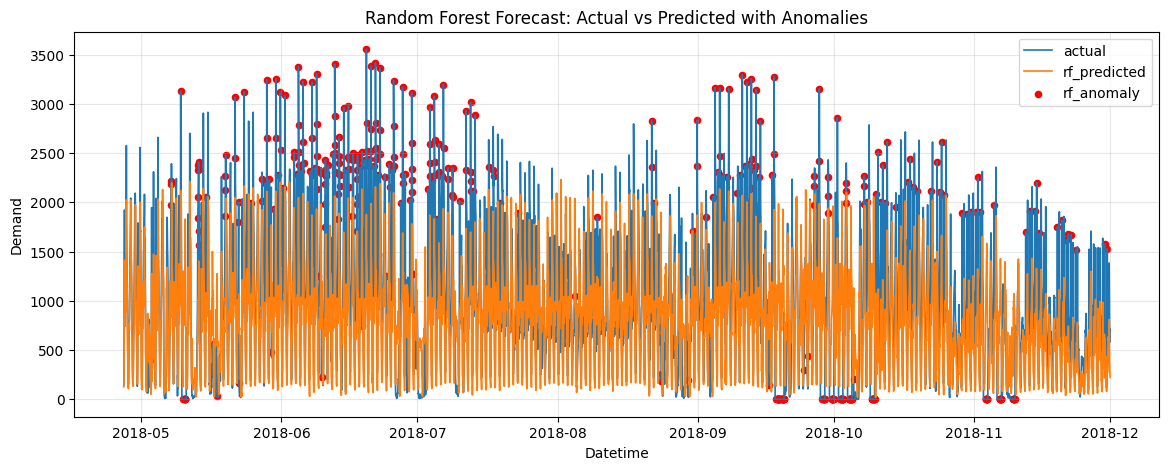

,datetime,city,demand,predicted_demand,residual,anomaly_type
24885,2018-10-09 18:00:00,Seoul,0,2056.994143,-2056.994143,unexpected_drop
24717,2018-10-02 18:00:00,Seoul,0,2011.370130,-2011.370130,unexpected_drop
24381,2018-09-18 18:00:00,Seoul,0,1985.081011,-1985.081011,unexpected_drop
24765,2018-10-04 18:00:00,Seoul,0,1964.523339,-1964.523339,unexpected_drop
24669,2018-09-30 18:00:00,Seoul,0,1962.134354,-1962.134354,unexpected_drop
24405,2018-09-19 18:00:00,Seoul,0,1930.027761,-1930.027761,unexpected_drop
21237,2018-05-10 18:00:00,Seoul,0,1830.307131,-1830.307131,unexpected_drop
24621,2018-09-28 18:00:00,Seoul,0,1827.754117,-1827.754117,unexpected_drop
22197,2018-06-19 18:00:00,Seoul,3556,1877.722810,1678.277190,unexpected_spike
25485,2018-11-03 18:00:00,Seoul,0,1583.003103,-1583.003103,unexpected_drop


In [33]:
# Step 9: Improved model (Random Forest) + anomaly comparison

from sklearn.ensemble import RandomForestRegressor

# Train on the same time-based split used before
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=18,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    )
rf_model.fit(X_train_t, y_train_t)

# Predict and clip negative values to 0 (demand cannot be negative)
rf_pred_t = rf_model.predict(X_test_t)
rf_pred_t = np.clip(rf_pred_t, 0, None)

rf_mae_t = mean_absolute_error(y_test_t, rf_pred_t)
rf_rmse_t = mean_squared_error(y_test_t, rf_pred_t) ** 0.5

model_compare_df = pd.DataFrame({
    "model": ["LinearRegression_time", "RandomForest_time"],
    "MAE": [mae_t, rf_mae_t],
    "RMSE": [rmse_t, rf_rmse_t],
})
print("Model comparison (time-based split):")
display(model_compare_df)

# Residual anomalies for Random Forest
rf_eval_df = time_df.iloc[split_idx:].copy()
rf_eval_df["predicted_demand"] = rf_pred_t
rf_eval_df["residual"] = rf_eval_df["demand"] - rf_eval_df["predicted_demand"]
rf_eval_df["abs_residual"] = rf_eval_df["residual"].abs()

rf_resid_std = rf_eval_df["residual"].std()
rf_threshold = 2 * rf_resid_std
rf_eval_df["is_anomaly"] = rf_eval_df["abs_residual"] > rf_threshold

rf_eval_df["anomaly_type"] = "normal"
rf_eval_df.loc[(rf_eval_df["is_anomaly"]) & (rf_eval_df["residual"] > 0), "anomaly_type"] = "unexpected_spike"
rf_eval_df.loc[(rf_eval_df["is_anomaly"]) & (rf_eval_df["residual"] < 0), "anomaly_type"] = "unexpected_drop"

print("\nRandom Forest anomaly summary:")
print("Residual std:", round(rf_resid_std, 3))
print("Anomaly threshold (2*std):", round(rf_threshold, 3))
print("Anomalies found:", int(rf_eval_df["is_anomaly"].sum()))
print("Anomaly rate (%):", round(100 * rf_eval_df["is_anomaly"].mean(), 2))

# Plot RF actual vs predicted with anomalies
plt.figure(figsize=(14, 5))
plt.plot(rf_eval_df["datetime"], rf_eval_df["demand"], label="actual", linewidth=1.2)
plt.plot(rf_eval_df["datetime"], rf_eval_df["predicted_demand"], label="rf_predicted", linewidth=1.2)
rf_anoms = rf_eval_df[rf_eval_df["is_anomaly"]]
plt.scatter(rf_anoms["datetime"], rf_anoms["demand"], color="red", s=20, label="rf_anomaly")
plt.title("Random Forest Forecast: Actual vs Predicted with Anomalies")
plt.xlabel("Datetime")
plt.ylabel("Demand")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

rf_top_anomalies = rf_eval_df.sort_values("abs_residual", ascending=False)[[
    "datetime", "city", "demand", "predicted_demand", "residual", "anomaly_type"
]].head(10)
rf_top_anomalies

Random Forest, compare it against Linear Regression, and generate an updated anomaly plot so you can see the improvement directly

--------------------------------------------------------------

Top features driving bike demand prediction:


,feature,importance
6,hour,0.410864
0,temperature,0.369026
1,humidity,0.082518
7,day_of_week,0.040698
2,windspeed,0.031424
8,month,0.020219
9,is_weekend,0.019486
5,season_code,0.010588
4,holiday_bin,0.006442
3,rainfall,0.005426


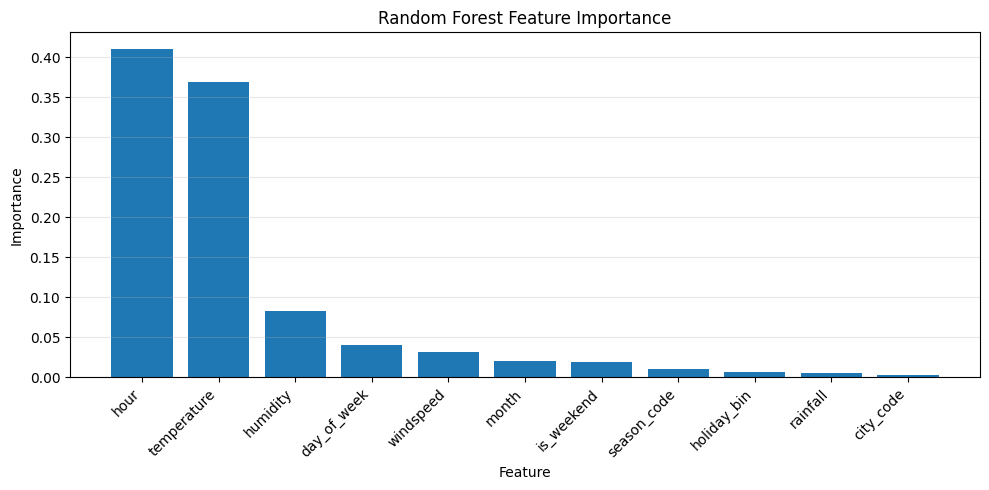

In [35]:
# Step 11: Interpretability with Random Forest feature importance

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False)

print("Top features driving bike demand prediction:")
display(importance_df)

plt.figure(figsize=(10, 5))
plt.bar(importance_df["feature"], importance_df["importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Final Findings and Conclusions

1. Time-aware evaluation is essential for forecasting.
- Random split was optimistic (MAE 191.148, RMSE 299.787).
- Time-based split was harder and more realistic (MAE 460.759, RMSE 599.677).

2. Random Forest improved forecasting quality over Linear Regression on time-based evaluation.
- LinearRegression_time: MAE 460.759, RMSE 599.677
- RandomForest_time: MAE 356.187, RMSE 473.116

3. Cross-city transferability was weak.
- Train DC -> Test Seoul: MAE 9819.417, RMSE 10952.633
- Train Seoul -> Test DC: MAE 584.887, RMSE 622.179
- Interpretation: demand dynamics differ strongly across cities, so models do not generalize well without adaptation.

4. Residual-based anomalies were meaningful after adding context.
- Original RF anomalies: 394
- Context-aware RF anomalies: 278
- Non-operational rows excluded: 271
- Interpretation: many false alarms were removed by accounting for non-operating periods.

5. The strongest demand drivers were time-of-day and weather.
- Top feature importances:
  - hour: 0.4109
  - temperature: 0.3690
  - humidity: 0.0825
- Interpretation: commute timing and thermal comfort are major demand predictors in this data.

6. Practical project takeaway.
- A robust bike-demand pipeline should use time-based validation, nonlinear models, and operational-context filtering for anomaly detection.
- This improves realism and trust in detected anomalies.

In [34]:
# Step 10: Context-aware anomalies (handle non-operating periods)

# Build an operation flag from Seoul raw data when available
if "Functioning Day" in seoul.columns:
    seoul_ops = seoul.copy()
    seoul_ops["datetime"] = pd.to_datetime(seoul_ops["Date"], dayfirst=True) + pd.to_timedelta(seoul_ops["Hour"], unit="h")
    seoul_ops["is_operational"] = (
        seoul_ops["Functioning Day"].astype(str).str.strip().str.lower()
        .isin(["functioning day", "fun", "yes", "1", "true"])
        .astype(int)
    )
    seoul_ops = seoul_ops[["datetime", "is_operational"]].copy()
else:
    # Fallback: if column is unavailable, treat all periods as operational
    seoul_ops = pd.DataFrame(columns=["datetime", "is_operational"])

rf_eval_ctx = rf_eval_df.copy()
rf_eval_ctx["is_operational"] = 1

# Attach Seoul operation flags by datetime
if not seoul_ops.empty:
    rf_eval_ctx = rf_eval_ctx.merge(seoul_ops, on="datetime", how="left", suffixes=("", "_seoul"))
    seoul_mask = rf_eval_ctx["city"] == "Seoul"
    rf_eval_ctx.loc[seoul_mask, "is_operational"] = rf_eval_ctx.loc[seoul_mask, "is_operational_seoul"].fillna(1).astype(int)
    rf_eval_ctx = rf_eval_ctx.drop(columns=[c for c in ["is_operational_seoul"] if c in rf_eval_ctx.columns])

# Recompute anomalies only for operational periods
rf_eval_ctx["is_anomaly_context"] = (rf_eval_ctx["is_operational"] == 1) & (rf_eval_ctx["abs_residual"] > rf_threshold)

print("Original RF anomalies:", int(rf_eval_df["is_anomaly"].sum()))
print("Context-aware RF anomalies:", int(rf_eval_ctx["is_anomaly_context"].sum()))
print("Rows excluded as non-operational:", int((rf_eval_ctx["is_operational"] == 0).sum()))

# Compare top context-aware anomalies
rf_top_ctx_anomalies = rf_eval_ctx[rf_eval_ctx["is_anomaly_context"]].sort_values("abs_residual", ascending=False)[[
    "datetime", "city", "demand", "predicted_demand", "residual", "anomaly_type", "is_operational"
]].head(10)
rf_top_ctx_anomalies

Original RF anomalies: 394
Context-aware RF anomalies: 278
Rows excluded as non-operational: 271


,datetime,city,demand,predicted_demand,residual,anomaly_type,is_operational
1286,2018-06-19 18:00:00,Seoul,3556,1877.722810,1678.277190,unexpected_spike,1
4324,2018-10-24 08:00:00,Seoul,2108,554.427276,1553.572724,unexpected_spike,1
1067,2018-06-10 15:00:00,Seoul,2182,684.260398,1497.739602,unexpected_spike,1
1478,2018-06-27 18:00:00,Seoul,3172,1689.830905,1482.169095,unexpected_spike,1
1191,2018-06-15 19:00:00,Seoul,2984,1508.315107,1475.684893,unexpected_spike,1
4180,2018-10-18 08:00:00,Seoul,2154,699.204800,1454.795200,unexpected_spike,1
4972,2018-11-20 08:00:00,Seoul,1818,364.439658,1453.560342,unexpected_spike,1
1068,2018-06-10 16:00:00,Seoul,2333,895.733165,1437.266835,unexpected_spike,1
1108,2018-06-12 08:00:00,Seoul,2495,1061.435988,1433.564012,unexpected_spike,1
3998,2018-10-10 18:00:00,Seoul,2514,1087.053496,1426.946504,unexpected_spike,1
